# Pipeline Principal — Hopifield
Executa as etapas de pré-processamento e análise da matriz de expressão.

## 1. Binarização

In [9]:
import sys, os, importlib

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import config, preprocessing
importlib.reload(config)
importlib.reload(preprocessing)
from config import PATH_M, PATH_F, OUT_BINARIZACAO
from preprocessing import Binarizador

# --- Binarização dos dois datasets ---
binarizador_m = Binarizador(path_h5ad=PATH_M, out_dir=OUT_BINARIZACAO)
binarizador_f = Binarizador(path_h5ad=PATH_F, out_dir=OUT_BINARIZACAO)

binarizador_m.binarizar()
binarizador_f.binarizar()

print("Mathys binarizado em:", binarizador_m.path_binarizada)
print("Fujita binarizado em:", binarizador_f.path_binarizada)

[Binarizador] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaMParcial\matrizBinarizadaM.h5ad
[Binarizador] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaF\matrizBinarizadaM.h5ad
Mathys binarizado em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaMParcial\matrizBinarizadaM.h5ad
Fujita binarizado em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaF\matrizBinarizadaM.h5ad


## 2. Alinhamento

In [10]:
import sys, os, importlib
import anndata as ad

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import config, alinhamento
importlib.reload(config)
importlib.reload(alinhamento)
from config import PATH_FEATURES_F, PATH_FEATURES_M, PATH_TOP5000, OUT_ALINHAMENTO, OUT_TOP_GENES
from alinhamento import (LeitorFeatures, AnalisadorSobreposicao, Alinhador,
                          ValidadorAlinhamento, AnalisadorCobertura,
                          SelecionadorGenesFrequentes)

In [11]:
# Passo 1 — Leitura dos arquivos de features
leitor = LeitorFeatures(PATH_FEATURES_F, PATH_FEATURES_M)
leitor.ler()
print(leitor)

[LeitorFeatures] Fujita : 36591 genes mapeados
[LeitorFeatures] Mathys : 32643 genes mapeados
LeitorFeatures(
  path_features_f = C:\Users\Leticia\Documents\Letworkspace\Sweep-Harmonization\Meus_testes\Controle_qualidade\dataF\dados_combinados\features.tsv\features.tsv
  path_features_m = C:\Users\Leticia\Documents\Letworkspace\Sweep-Harmonization\Meus_testes\Controle_qualidade\dataM\featuresM.tsv.gz
  map_f           = 36591 genes
  map_m           = 32643 genes
)


In [12]:
# Passo 2 — Análise de sobreposição
from config import PATH_F

# var_names são idênticos no original e no binarizado — lemos direto do original
_f = ad.read_h5ad(PATH_F, backed='r')
var_names_f_original = _f.var_names.tolist()
_f.file.close()
del _f

analisador = AnalisadorSobreposicao(leitor.map_f, leitor.map_m, var_names_f_original)
analisador.analisar()
print(analisador)

[AnalisadorSobreposicao] Em comum  : 30312
[AnalisadorSobreposicao] Só Fujita : 6279
[AnalisadorSobreposicao] Só Mathys : 2331  ← serão excluídos
[AnalisadorSobreposicao] Espaço gênico final: 36601 genes
AnalisadorSobreposicao(
  ids_comuns      = 30312
  ids_so_f        = 6279
  ids_so_m        = 2331
  genes_ordenados = 36601
)


In [13]:
# Passo 3 — Alinhamento dos dois h5ad binarizados
alinhador = Alinhador(
    path_binarizada_m = binarizador_m.path_binarizada,
    path_binarizada_f = binarizador_f.path_binarizada,
    out_dir           = OUT_ALINHAMENTO,
    map_f             = leitor.map_f,
    map_m             = leitor.map_m,
    gene_alvo_idx     = analisador.gene_alvo_idx,
    genes_ordenados   = analisador.genes_ordenados,
)
alinhador.alinhar()
alinhador.salvar_como_txt()
alinhador.gerar_tracking(analisador.ids_so_f, leitor.map_f)
print(alinhador)

[Alinhador] Carregando Fujita binarizado...
  shape original: (40913, 36601)
[Alinhador] Alinhando Fujita (fill=0.0)...
  shape final: (40913, 36601)
  salvo em c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad  ✓

[Alinhador] Carregando Mathys binarizado...
  shape original: (47523, 32738)
[Alinhador] Alinhando Mathys (genes ausentes → 0.5)...
  Preenchendo 6289 colunas ausentes com 0.5...
  Preenchimento concluído.
  shape final: (47523, 36601)
  salvo em c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.h5ad  ✓

[Alinhador] Concluído.
[Alinhador] TXT já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.txt
[Alinhador] TXT já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamen

In [16]:
# Passo 4 — Validação da ordem de genes
validador = ValidadorAlinhamento(
    path_f_alinhado = alinhador.path_f_alinhado,
    path_m_alinhado = alinhador.path_m_alinhado,
    genes_ordenados = analisador.genes_ordenados,
)
validador.validar()

[ValidadorAlinhamento] Carregando metadados...
✓ Número de genes idêntico: 36601
✓ Fujita alinhado == ordem de referência
✓ Mathys alinhado == ordem de referência
✓ Fujita alinhado == Mathys alinhado
[ValidadorAlinhamento] Validação concluída com sucesso.


ValidadorAlinhamento(
  path_f_alinhado  = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
  path_m_alinhado  = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.h5ad
  genes_ordenados  = 36601 genes
)

In [17]:
# Passo 5 — Cobertura dos top-5000 genes frequentes do Fujita no Mathys
cobertura = AnalisadorCobertura(PATH_TOP5000, leitor.map_f, leitor.map_m)
cobertura.analisar(out_csv=os.path.join(OUT_ALINHAMENTO, "top5000_cobertura_mathys.csv"))


  Top 5000 genes frequentes do Fujita
  Presentes no Mathys       :  4906  (98.1%)
  Ausentes no Mathys (zeros):    94  (1.9%)
  Sem Ensembl ID no Fujita  :     0  (0.0%)

[AnalisadorCobertura] Resultado salvo em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\top5000_cobertura_mathys.csv


gene_name,frequencia,ensembl_id,presente_mathys,sem_ensembl_fujita
str,i64,str,bool,bool
"""MALAT1""",40782,"""ENSG00000251562""",true,false
"""CADM2""",39065,"""ENSG00000175161""",true,false
"""PCDH9""",39012,"""ENSG00000184226""",true,false
"""SNHG14""",38439,"""ENSG00000224078""",false,false
"""DLG2""",38107,"""ENSG00000150672""",true,false
…,…,…,…,…
"""METTL26""",11033,"""ENSG00000130731""",true,false
"""NDUFAF5""",11031,"""ENSG00000101247""",true,false
"""CALU""",11030,"""ENSG00000128595""",true,false


## 3. Preparação do conjunto de treinamento

In [ ]:
import sys, os, importlib

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import config, alinhamento, treinamento

# Recarrega submódulos explicitamente antes dos pacotes
import alinhamento.selecionador_genes_frequentes as _sgf_mod
import treinamento.gerador_conjunto_treinamento  as _gct_mod
import treinamento.projetor_sweep               as _ps_mod
importlib.reload(_sgf_mod)
importlib.reload(_gct_mod)
importlib.reload(_ps_mod)
importlib.reload(config)
importlib.reload(alinhamento)
importlib.reload(treinamento)

from config import OUT_TOP_GENES, OUT_TREINAMENTO, PATH_SWEEP_F
from alinhamento import SelecionadorGenesFrequentes
from treinamento import GeradorConjuntoTreinamento, ProjetorSWeePR

path_top5k    = os.path.join(OUT_TOP_GENES,   "top5000_frequentes.csv")
path_f_top5k  = os.path.join(OUT_TREINAMENTO, "adataF_binarizado_alinhado_top5000.txt")
path_m_top5k  = os.path.join(OUT_TREINAMENTO, "adataM_binarizado_alinhado_top5000.txt")

# — Passo 3a: Top 5000 genes mais frequentes do Fujita —
selecionador = SelecionadorGenesFrequentes(
    path_txt = alinhador.path_f_alinhado.replace('.h5ad', '.txt'),
    n        = 5000,
)
selecionador.calcular(out_csv=path_top5k).salvar(path_top5k)

# — Passo 3b: Conjuntos de treinamento filtrados (Fujita + Mathys) —
gerador = GeradorConjuntoTreinamento(
    path_top_genes_csv = path_top5k,
    out_dir            = OUT_TREINAMENTO,
)
gerador.gerar(alinhador.path_f_alinhado.replace('.h5ad', '.txt'))
gerador.gerar(alinhador.path_m_alinhado.replace('.h5ad', '.txt'))

# — Passo 3c: Projeção SWeeP via R (células × 600 dim) —
projetor_r = ProjetorSWeePR(
    path_matriz   = path_f_top5k,
    path_saida    = PATH_SWEEP_F,
    n_componentes = 600,
    seed          = 42,
)
projetor_r.projetar()

print("\n=== Arquivos de treinamento prontos ===")
for label, path in [
    ("top5000_frequentes.csv            ", path_top5k),
    ("adataF_binarizado_alinhado_top5000", path_f_top5k),
    ("adataM_binarizado_alinhado_top5000", path_m_top5k),
    ("matriz_reduzida_sweepF.csv        ", PATH_SWEEP_F),
]:
    status = "✓" if os.path.exists(path) else "✗ NÃO ENCONTRADO"
    print(f"  {label} : {status}")

## 4. Análise Hopfield (rede35)

In [12]:
import sys, os, importlib
import numpy as np
import pandas as pd

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import config, treinamento
import treinamento.carregador_dados_fujita as _cdf_mod
importlib.reload(_cdf_mod)
importlib.reload(config)
importlib.reload(treinamento)

from config import PATH_SWEEP_F, PATH_LABELS_F, OUT_TREINAMENTO, OUT_TOP_GENES
from treinamento import CarregadorDadosFujita

# Passo 4a — Carregamento dos dados Fujita (padrões para treino da rede)
path_matriz_f = os.path.join(OUT_TREINAMENTO, "adataF_binarizado_alinhado_top5000.txt")
path_genes    = os.path.join(OUT_TOP_GENES,   "top5000_frequentes.csv")

carregador = CarregadorDadosFujita(
    path_matriz = path_matriz_f,
    path_genes  = path_genes,
    path_labels = PATH_LABELS_F,
    path_sweep  = PATH_SWEEP_F,
    n_genes     = 5000,
)
carregador.carregar()
print(carregador)

# Passo 4a.2 — Carregamento da matriz Mathys (usada na reconstrução)
mapeamento_mathys = {
    'Ex' : 3,   # Excitatory Neurons
    'In' : 4,   # Inhibitory Neurons
    'Oli': 6,   # Oligodendrocytes
    'Opc': 7,   # OPCs
    'Ast': 1,   # Astrocyte
    'Mic': 5,   # Microglia
    'End': 2,   # Endothelial
    'Per': 8,   # Pericytes
}

path_matriz_m   = os.path.join(OUT_TREINAMENTO, "adataM_binarizado_alinhado_top5000.txt")
path_anotacao_m = os.path.join("outputs", "celltypeMparcial.csv")

print("[Mathys] Carregando matriz top5000...")
W_mathys = pd.read_csv(path_matriz_m).to_numpy(dtype=np.float32)
print(f"[Mathys] W_mathys shape: {W_mathys.shape}")

print("[Mathys] Carregando anotação e convertendo para rótulos numéricos...")
df_anotacao   = pd.read_csv(path_anotacao_m)
labels_mathys = df_anotacao['celltype'].map(mapeamento_mathys).fillna(0).astype(int).values
print(f"[Mathys] labels shape: {labels_mathys.shape}, tipos: {np.unique(labels_mathys)}")

[CarregadorDadosFujita] Carregando matriz: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_top5000.txt
[CarregadorDadosFujita] Matriz carregada: (40913, 5000)
[CarregadorDadosFujita] Selecionando top 5000 genes por frequência...
[CarregadorDadosFujita] W0 shape: (40913, 5000)
[CarregadorDadosFujita] Carregando genes: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\top5000_frequentes.csv
[CarregadorDadosFujita] 5000 genes carregados
[CarregadorDadosFujita] Carregando rótulos: C:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\dadosExternos\cell_types_binario.txt
[CarregadorDadosFujita] Rótulos shape: (40913,), tipos: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
[CarregadorDadosFujita] Carregando SWeeP pré-computado: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF.csv
[CarregadorDadosFujita] Wswp shape: (40913, 600)
[Carregador

In [13]:
from treinamento import ProjetorSWeP

# Passo 4b — Aplicar PCA sem centralização sobre as projeções SWeeP
projetor = ProjetorSWeP(n_features=5000)
projetor.usar_sweep_precomputado(carregador.Wswp).aplicar_pca()
print(projetor)

[ProjetorSWeP] SWeeP pré-computado definido: (40913, 600)
[ProjetorSWeP] Aplicando PCA sem centralização...
[ProjetorSWeP] Wpc shape: (40913, 600)
ProjetorSWeP(
  n_features    = 5000
  n_componentes = 600
  seed          = 42
  R             = não gerada
  Wswp          = (40913, 600)
  Wpc           = (40913, 600)
)


In [14]:
from treinamento import ExtratorPadroesSubcluster

# Passo 4c — Extração de padrões por subcluster (perf35: 7 classes × 10 representantes)
extrator = ExtratorPadroesSubcluster(
    W0      = carregador.W0,
    labels  = carregador.labels,
    classes = [1, 3, 4, 5, 6, 7, 2],
    nc      = 10,
    seed    = 42,
)
extrator.extrair(projetor.Wswp)
print(extrator)

[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 6: n=5762, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 2: n=188, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Extração concluída: 70 padrões (7 classes × 10)
ExtratorPadroesSubcluster(
  W0       = (40913, 5000)
  labels   = (40913,)
  classes  = [1, 3, 4, 5, 6, 7, 2]
  nc       = 10
  seed     = 42
  padroes  = (70, 5000)
)


In [15]:
import sys, os, importlib

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import config, treinamento
import treinamento.hopfield as _hopfield_mod
importlib.reload(_hopfield_mod)
importlib.reload(config)
importlib.reload(treinamento)

from config import OUT_HOPFIELD
from treinamento import ModernHopfieldNetwork

# Passo 4d — Treino com padrões Fujita + reconstrução com Mathys
rede35 = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True)
rede35.store(extrator.padroes)   # treino: padrões extraídos do Fujita

# Salva rede treinada (transferível entre máquinas)
path_rede = os.path.join(OUT_HOPFIELD, "rede35_treinada.pt")
rede35.salvar(path_rede)

# Recuperação usando a matriz do Mathys
Wrecuperado = rede35.retrieve(W_mathys, batch_size=4096)
print(rede35)

[ModernHopfieldNetwork] 70 padrões armazenados (dim=5000, device=cpu)
[ModernHopfieldNetwork] Rede salva em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_treinada.pt (70 padrões × 5000 dim)
[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
ModernHopfieldNetwork(
  beta       = 8.0
  n_iters    = 1
  binary     = True
  threshold  = 0.0
  padrões    = 70 × 5000
)


### Carregamento da rede treinada (segunda máquina)
Execute esta célula caso esteja continuando a análise a partir do arquivo `.pt` gerado na outra máquina.
Não é necessário reexecutar o treinamento — basta carregar o arquivo e seguir para o passo 4e.

In [16]:
import sys, os, importlib
import numpy as np
import pandas as pd

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import config, treinamento
import treinamento.hopfield as _hopfield_mod
importlib.reload(_hopfield_mod)
importlib.reload(config)
importlib.reload(treinamento)

from config import OUT_HOPFIELD, OUT_TREINAMENTO
from treinamento import ModernHopfieldNetwork

# Carrega rede treinada salva na outra máquina
path_rede = os.path.join(OUT_HOPFIELD, "rede35_treinada.pt")
rede35 = ModernHopfieldNetwork.carregar(path_rede)
print(rede35)

# Carrega matriz Mathys para recuperação
mapeamento_mathys = {
    'Ex' : 3, 'In' : 4, 'Oli': 6, 'Opc': 7,
    'Ast': 1, 'Mic': 5, 'End': 2, 'Per': 8,
}
path_matriz_m   = os.path.join(OUT_TREINAMENTO, "adataM_binarizado_alinhado_top5000.txt")
path_anotacao_m = os.path.join("outputs", "celltypeMparcial.csv")

W_mathys = pd.read_csv(path_matriz_m).to_numpy(dtype=np.float32)
print(f"[Mathys] W_mathys shape: {W_mathys.shape}")

df_anotacao   = pd.read_csv(path_anotacao_m)
labels_mathys = df_anotacao['celltype'].map(mapeamento_mathys).fillna(0).astype(int).values
print(f"[Mathys] labels shape: {labels_mathys.shape}, tipos: {np.unique(labels_mathys)}")

# Recuperação
Wrecuperado = rede35.retrieve(W_mathys, batch_size=4096)

[ModernHopfieldNetwork] Rede carregada de: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_treinada.pt (70 padrões × 5000 dim)
ModernHopfieldNetwork(
  beta       = 8.0
  n_iters    = 1
  binary     = True
  threshold  = 0.0
  padrões    = 70 × 5000
)
[Mathys] W_mathys shape: (45663, 5000)
[Mathys] labels shape: (45663,), tipos: [1 2 3 4 5 6 7 8]
[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])


[AvaliadorHopfield] Mapeando padrões recuperados para classes...
[AvaliadorHopfield] Acurácia: 8.94% (n=45,663)
[AvaliadorHopfield] F1 macro=0.0461, F1 ponderado=0.1377
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      2597
           3       0.92      0.12      0.21     24548
           4       0.08      0.08      0.08      6420
           5       0.00      0.01      0.00       485
           6       0.08      0.07      0.08      9218
           7       0.00      0.00      0.00      2236
           2       0.00      0.85      0.00        68

   micro avg       0.09      0.09      0.09     45572
   macro avg       0.16      0.16      0.05     45572
weighted avg       0.52      0.09      0.14     45572



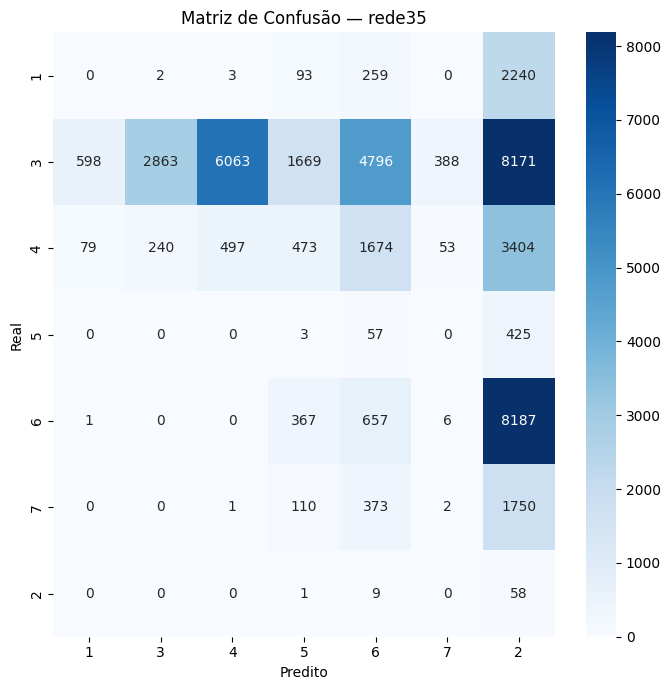

AvaliadorHopfield(
  padroes     = (70, 5000)
  classes     = [1, 3, 4, 5, 6, 7, 2]
  nc          = 10
  acuracia    = 8.94%
  f1_macro    = 0.0461
  f1_weighted = 0.1377
)


In [17]:
from treinamento import AvaliadorHopfield

# Passo 4e — Avaliação: reconstrução Mathys vs rótulos Mathys
avaliador = AvaliadorHopfield(
    padroes = extrator.padroes,
    classes = [1, 3, 4, 5, 6, 7, 2],
    nc      = 10,
)
avaliador.avaliar(Wrecuperado, labels_mathys).plotar()
print(avaliador)